# Family-Aware Robustness Study: Final Comparison

This notebook presents the final evaluation of a redesigned document-routing pipeline for
government forms (USCIS, California DMV, SSA, and IRS), comparing three classification
methods: a fine-tuned BERT classifier trained on document chunks, a plain large language
model (LLM) classifier (Gemini), and a retrieval-augmented variant (LLM+RAG). The study
addresses two limitations identified in the original evaluation: **family leakage**, in which
near-duplicate, translated, or closely related document variants ("form families") could
appear on both sides of a train/test split, and the absence of any **robustness testing**
under partial input or identifier masking.

The comparison below evaluates all three methods on the same 99 held-out test documents,
drawn from form families entirely excluded from training, under ten evaluation conditions:
the complete document text, four partial-input excerpts (beginning, middle, end, and a
combined beginning-middle-end excerpt), each in both an unmasked and a masked
(agency-identifier-removed) form. The full methodology is documented in
`Robustness_v6_Family_Aware_Chunked_BERT.md`.

Every result in this notebook is read from evaluation artifacts already produced and saved by
the project's data-processing and evaluation pipeline. No model is retrained, no retrieval
index is rebuilt, no embedding is recomputed, and no language-model API call is made in the
course of running this notebook -- every number below reflects computation that was already
performed and recorded when the underlying evaluation was run.

> **Provenance:** This notebook synthesizes artifacts produced by `train_bert`, `evaluate_bert`, `build_rag_index`, `evaluate_llm`, and `evaluate_rag` (MVP/), and is reproduced without any of them being rerun -- see `MVP/docs/ARTIFACTS.md` and `python -m newstart_ai_mvp.compare_models` for the same headline numbers on demand.

### Setup

This section loads the project configuration and defines the file paths from which every
subsequent artifact in this notebook is read. Consolidating file access here makes explicit
that the remainder of the notebook is read-only with respect to the research pipeline: no
path referenced below is ever written to.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


from newstart_ai_mvp.config import load_settings  # installed package -- no sys.path needed

settings = load_settings()
manifests_dir = settings.resolve_path("artifacts/family_aware/manifests")
reports_dir = settings.resolve_path("artifacts/family_aware/reports")
split_dir = settings.resolve_path(settings.family_aware.split.output_dir)


def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


CONDITIONS = [
    "complete_unmasked", "beginning_only_unmasked", "middle_only_unmasked", "end_only_unmasked",
    "beginning_middle_end_unmasked", "complete_masked", "beginning_only_masked", "middle_only_masked",
    "end_only_masked", "beginning_middle_end_masked",
]
METHOD_LABELS = {"bert": "Family-aware BERT", "llm": "Plain Gemini LLM", "llm_rag": "Gemini LLM+RAG"}
print("Settings loaded. Reading artifacts from:", manifests_dir)

Settings loaded. Reading artifacts from: D:\USD\Projects\a590\newstart-ai\newstart_ai_benchmark\artifacts\family_aware\manifests


## 1. Family-aware document split and long-document chunking

Every result in this notebook depends on the integrity of the underlying data split, so this
section begins by summarizing it: the number of eligible documents and form families
assigned to the training, validation, and test partitions, and confirmation -- drawn directly
from the saved split manifest rather than recomputed here -- that no document or form family
appears in more than one partition, and that all four target agencies are represented in
every partition. This document- and family-disjoint split is the methodological safeguard
that distinguishes this evaluation from the original one.

In [2]:
split_manifest = load_json(split_dir / "family_split_manifest_v1.json")

split_summary = pd.DataFrame(
    [
        {
            "Split": s["split"],
            "Documents": s["document_count"],
            "Form families": s["family_count"],
            "% of eligible documents": s["percentage_of_eligible_documents"],
            **{f"{a['agency']} documents": a["document_count"] for a in s["by_agency"]},
        }
        for s in split_manifest["splits"]
    ]
)


def yes_no(value):
    return "Yes" if value else "No"


print(f"Total eligible documents: {split_manifest['total_eligible_documents']}")
print(f"Total eligible form families: {split_manifest['total_eligible_families']}")
print(f"No document appears in more than one split: {yes_no(split_manifest['zero_document_overlap'])}")
print(f"No form family appears in more than one split: {yes_no(split_manifest['zero_family_overlap'])}")
print(f"All four agencies represented in every split: {yes_no(split_manifest['all_agencies_in_every_split'])}")
split_summary

Total eligible documents: 659
Total eligible form families: 510
No document appears in more than one split: Yes
No form family appears in more than one split: Yes
All four agencies represented in every split: Yes


,Split,Documents,Form families,% of eligible documents,DMV documents,IRS documents,SSA documents,USCIS documents
0,train,461,355,69.95,183,17,104,157
1,validation,99,78,15.02,39,4,22,34
2,test,99,77,15.02,39,4,22,34


## 2. Long-document training balance

Long training documents can dominate a chunk-level training objective simply by contributing
far more chunks than an average document, unless that imbalance is explicitly corrected. This
section illustrates the effect of the document-balancing policy applied during training,
using the single largest training document (519 chunks) as an example: its share of raw
training chunks compared with its actual weighted contribution to the training loss, alongside
the per-agency class weights used to address the corpus's agency imbalance (IRS documents are
comparatively rare).

In [3]:
balancing = load_json(manifests_dir / "document_balancing_verification_v1.json")
class_weights = load_json(manifests_dir / "agency_class_weights_v1.json")

print(
    f"Largest training document (id 739, 519 chunks) -- total weighted contribution to the "
    f"training loss: {balancing['document_739_total_weight']:.3f} (each document's chunk "
    f"weights are normalized to sum to 1, regardless of its length)."
)
print(f"All per-document weight sums equal 1: {yes_no(balancing['all_per_document_weight_sums_equal_one'])}")
print()

class_weight_df = pd.DataFrame(
    {
        "Agency": class_weights["label_order"],
        "Training documents": [class_weights["training_document_counts"][a] for a in class_weights["label_order"]],
        "Class weight": [round(class_weights["raw_weights"][a], 4) for a in class_weights["label_order"]],
    }
)
class_weight_df

Largest training document (id 739, 519 chunks) -- total weighted contribution to the training loss: 1.000 (each document's chunk weights are normalized to sum to 1, regardless of its length).
All per-document weight sums equal 1: Yes



,Agency,Training documents,Class weight
0,USCIS,157,0.7341
1,DMV,183,0.6298
2,SSA,104,1.1082
3,IRS,17,6.7794


## 3. BERT training history and checkpoint selection

This section shows the fine-tuned BERT classifier's per-epoch training and validation loss,
together with validation document-level macro F1, and identifies which training epoch was
selected as the final model. Model selection used validation performance only, never the
held-out test set -- the plot and table below are the saved record of exactly how that
selection was made.

Best epoch: 2 (validation macro F1 = 1.0000)
Stopping reason: Completed all 6 configured epochs (no early-stopping trigger configured); selected epoch 2 by highest validation document-level macro F1 (validation_macro_f1).


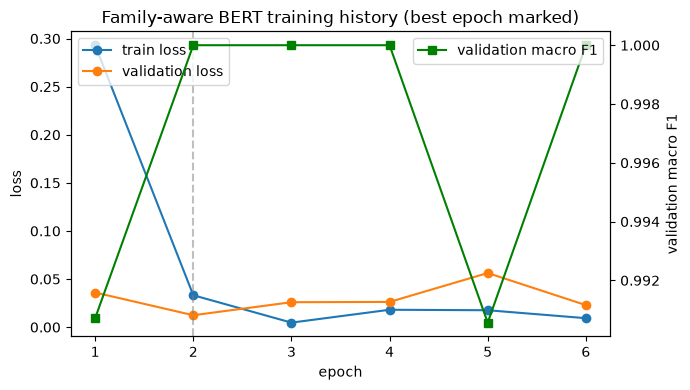

,epoch,train_loss,validation_loss,validation_document_macro_f1,validation_document_accuracy,learning_rate,epoch_duration_seconds
0,1,0.293084,0.036008,0.990713,0.989899,0.00002,105.135957
1,2,0.033180,0.012386,1.000000,1.000000,0.00002,105.698194
2,3,0.004709,0.025930,1.000000,1.000000,0.00002,105.403905
3,4,0.018083,0.026226,1.000000,1.000000,0.00002,105.354221
4,5,0.017587,0.056275,0.990563,0.989899,0.00002,105.662344
5,6,0.009330,0.022930,1.000000,1.000000,0.00002,104.318578


In [4]:
fa_model_dir = settings.resolve_path(settings.family_aware.training.output_dir)
bert_artifact_id = "3e4c71a6758249aabe262fa12e39cce4"
bert_metadata = load_json(fa_model_dir / bert_artifact_id / "metadata.json")

history_df = pd.DataFrame(bert_metadata["history"])
print(f"Best epoch: {bert_metadata['best_epoch']} (validation macro F1 = {bert_metadata['best_validation_document_macro_f1']:.4f})")
print(f"Stopping reason: {bert_metadata['stopping_reason']}")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
ax1.plot(history_df["epoch"], history_df["validation_loss"], marker="o", label="validation loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(history_df["epoch"], history_df["validation_document_macro_f1"], marker="s", color="green", label="validation macro F1")
ax2.set_ylabel("validation macro F1"); ax2.legend(loc="upper right")
ax1.axvline(bert_metadata["best_epoch"], color="gray", linestyle="--", alpha=0.5)
plt.title("Family-aware BERT training history (best epoch marked)")
plt.tight_layout()
plt.show()
history_df

## 4. RAG retrieval diagnostics

Before the retrieval-augmented classifier was evaluated on the test set, the retrieval
component itself was validated in isolation, using the validation split only. This section
reports two such diagnostics: the effect of a diversification policy that prevents any single
long document from dominating a query's retrieved context (again using the largest training
document as an example), and retrieval-quality metrics -- agency hit rate and mean reciprocal
rank -- for each of the ten evaluation conditions. These are retrieval-quality metrics, not
classification accuracy; the classification results for LLM+RAG are reported in Section 5.

In [5]:
diversification = load_json(manifests_dir / "checkpoint9_diversification_effect_v1.json")
retrieval_diag = load_json(manifests_dir / "checkpoint9_validation_retrieval_diagnostics_v1.json")

print("Mean share of retrieved results coming from a single parent document:")
print(f"  before diversification: {diversification['mean_top_parent_share_before']:.3f}")
print(f"  after diversification:  {diversification['mean_top_parent_share_after']:.3f}")
print(
    f"Largest training document (id 739) -- maximum retrieved positions in a single query: "
    f"before={diversification['document_739_max_positions_before']}, "
    f"after={diversification['document_739_max_positions_after']} (cap = 2, enforced)."
)
print()
print(
    "These figures characterize retrieval quality -- whether relevant, same-agency reference "
    "chunks were retrieved -- rather than downstream classification accuracy, which is "
    "reported separately in Section 5."
)

retrieval_summary = pd.DataFrame(
    [
        {
            "Condition": r["condition"], "Masked": r["masked"], "Index used": r["index_used"],
            "Agency hit rate (%)": r["top_k_agency_hit_rate"], "Mean reciprocal rank": r["mean_reciprocal_rank"],
            "Mean similarity": r["mean_similarity"], "Queries with < k results (%)": r["percent_queries_with_fewer_than_k_results"],
        }
        for r in retrieval_diag["results"]
    ]
)
retrieval_summary

Mean share of retrieved results coming from a single parent document:
  before diversification: 0.527
  after diversification:  0.384
Largest training document (id 739) -- maximum retrieved positions in a single query: before=1, after=2 (cap = 2, enforced).

These figures characterize retrieval quality -- whether relevant, same-agency reference chunks were retrieved -- rather than downstream classification accuracy, which is reported separately in Section 5.


,Condition,Masked,Index used,Agency hit rate (%),Mean reciprocal rank,Mean similarity,Queries with < k results (%)
0,complete_unmasked,False,unmasked,100.00,0.9949,0.8128,7.07
1,beginning_only_unmasked,False,unmasked,100.00,1.0000,0.7941,7.07
2,middle_only_unmasked,False,unmasked,100.00,1.0000,0.8131,7.07
3,end_only_unmasked,False,unmasked,100.00,1.0000,0.8232,0.00
4,beginning_middle_end_unmasked,False,unmasked,100.00,1.0000,0.8265,10.10
5,complete_masked,True,masked,100.00,0.9933,0.8277,6.06
6,beginning_only_masked,True,masked,100.00,1.0000,0.8025,6.06
7,middle_only_masked,True,masked,100.00,0.9933,0.8172,6.06
8,end_only_masked,True,masked,98.99,0.9848,0.8284,0.00
9,beginning_middle_end_masked,True,masked,100.00,0.9924,0.8316,4.04


## 5. Head-to-head comparison on the primary condition

This is the central result of the study: document-level macro F1 and accuracy for the
family-aware BERT classifier, the plain Gemini LLM classifier, and the Gemini LLM+RAG
classifier, evaluated on the same 99 test documents under the primary condition (complete,
unmasked document text), together with a paired, document-by-document comparison across the
three methods. This evaluation was run once, on this fixed set of documents, and the results
were not altered afterward.

In [6]:
method_condition_metrics = load_json(manifests_dir / "checkpoint10_method_condition_metrics_v1.json")
metrics_df = pd.DataFrame(method_condition_metrics)

primary = metrics_df[metrics_df["condition"] == "complete_unmasked"][
    ["method", "document_count", "document_macro_f1", "document_accuracy", "macro_precision", "macro_recall", "coverage_rate", "error_count"]
].copy()
primary["method"] = primary["method"].map(METHOD_LABELS)
primary = primary.rename(columns={
    "method": "Method", "document_count": "Documents", "document_macro_f1": "Macro F1",
    "document_accuracy": "Accuracy", "macro_precision": "Macro precision", "macro_recall": "Macro recall",
    "coverage_rate": "Coverage (%)", "error_count": "Errors",
})
primary

,Method,Documents,Macro F1,Accuracy,Macro precision,Macro recall,Coverage (%),Errors
0,Family-aware BERT,99,1.0,1.0,1.0,1.0,100.0,0
10,Plain Gemini LLM,99,1.0,1.0,1.0,1.0,100.0,0
20,Gemini LLM+RAG,99,1.0,1.0,1.0,1.0,100.0,0


In [7]:
paired = load_json(manifests_dir / "checkpoint10_primary_paired_comparison_v1.json")

print(
    f"Of {paired['document_count']} test documents, all three methods agreed and were correct on "
    f"{len(paired['all_three_correct'])}, and all three were incorrect on {len(paired['all_three_incorrect'])}."
)
print(
    f"Documents where exactly one method erred: BERT only {len(paired['bert_only_errors'])}, "
    f"plain LLM only {len(paired['plain_llm_only_errors'])}, LLM+RAG only {len(paired['rag_only_errors'])}."
)
print(
    f"Documents where LLM+RAG corrected a plain-LLM error: {len(paired['rag_corrects_plain_llm'])}; "
    f"where LLM+RAG introduced a new error relative to the plain LLM: {len(paired['rag_breaks_plain_llm'])}."
)
print(f"Plain LLM and LLM+RAG agreed on {paired['plain_llm_and_rag_agreement_rate']}% of predictions.")
print()
print(
    "A method-only error count means every other method classified that document correctly and "
    "this method alone did not. With counts this small, these tallies are reported "
    "descriptively; Section 7 provides confidence intervals and hypothesis-test results for a "
    "more rigorous statistical comparison."
)

Of 99 test documents, all three methods agreed and were correct on 99, and all three were incorrect on 0.
Documents where exactly one method erred: BERT only 0, plain LLM only 0, LLM+RAG only 0.
Documents where LLM+RAG corrected a plain-LLM error: 0; where LLM+RAG introduced a new error relative to the plain LLM: 0.
Plain LLM and LLM+RAG agreed on 100.0% of predictions.

A method-only error count means every other method classified that document correctly and this method alone did not. With counts this small, these tallies are reported descriptively; Section 7 provides confidence intervals and hypothesis-test results for a more rigorous statistical comparison.


## 6. Robustness across all ten evaluation conditions

The primary result above reflects one condition; the purpose of this study was to also
measure how each method's accuracy holds up when only part of a document is available, and
when explicit agency identifiers are masked out. This section reports document-level macro F1
for every method under all ten conditions -- complete and four partial-input excerpts, each
masked and unmasked -- as a table and as a bar chart, so robustness (not only headline
accuracy on one condition) is visible directly.

In [8]:
pivot = metrics_df.pivot(index="condition", columns="method", values="document_macro_f1").reindex(CONDITIONS)
pivot = pivot.rename(columns=METHOD_LABELS)[[METHOD_LABELS["bert"], METHOD_LABELS["llm"], METHOD_LABELS["llm_rag"]]]
pivot.index.name = "Evaluation condition"
pivot.columns.name = "Document-level Macro F1"
pivot

Document-level Macro F1,Family-aware BERT,Plain Gemini LLM,Gemini LLM+RAG
Evaluation condition,,,
complete_unmasked,1.000000,1.0,1.0
beginning_only_unmasked,0.958730,1.0,1.0
middle_only_unmasked,1.000000,1.0,1.0
end_only_unmasked,0.991021,1.0,1.0
beginning_middle_end_unmasked,1.000000,1.0,1.0
complete_masked,0.966408,1.0,1.0
beginning_only_masked,0.966408,1.0,1.0
middle_only_masked,1.000000,1.0,1.0
end_only_masked,0.984205,1.0,1.0


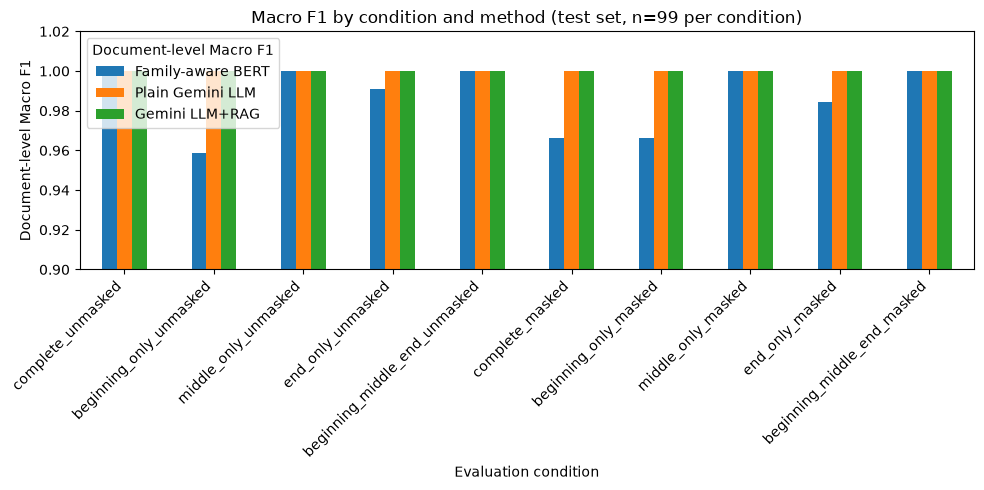

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Document-level Macro F1")
ax.set_ylim(0.9, 1.02)
ax.set_title("Macro F1 by condition and method (test set, n=99 per condition)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Statistical uncertainty

With 99 test documents in total, and as few as 4 for the IRS category, point estimates of
accuracy or macro F1 can convey more precision than the sample size supports. This section
reports bootstrap confidence intervals (fixed random seed, for reproducibility) around each
method's macro F1 and accuracy, together with pairwise McNemar comparisons between methods, so
that the precision of the headline results is stated explicitly rather than left implicit.

In [10]:
uncertainty = load_json(manifests_dir / "checkpoint10_statistical_uncertainty_v1.json")

bootstrap_df = pd.DataFrame(uncertainty["bootstrap_results"])
bootstrap_df["method"] = bootstrap_df["method"].map(METHOD_LABELS)
print(
    f"Bootstrap confidence intervals (seed = {uncertainty['seed']}, "
    f"{bootstrap_df['n_bootstrap'].iloc[0]} resamples):"
)
display_cols = ["method", "metric", "point_estimate", "ci_low", "ci_high"]
bootstrap_display = bootstrap_df[display_cols].rename(columns={
    "method": "Method", "metric": "Metric", "point_estimate": "Point estimate",
    "ci_low": "CI low", "ci_high": "CI high",
})
print(bootstrap_display.to_string(index=False))
print()
for m in uncertainty["mcnemar_results"]:
    print(
        f"McNemar's test, {METHOD_LABELS.get(m['method_a'], m['method_a'])} vs. "
        f"{METHOD_LABELS.get(m['method_b'], m['method_b'])}: {m['note']}"
    )
print()
print(
    "With only 99 test documents -- and as few as 4 for the IRS category -- these confidence "
    "intervals are wide, and any hypothesis-test result above should be read as suggestive at "
    "most, not as definitive evidence of one method's superiority."
)

Bootstrap confidence intervals (seed = 42, 5000 resamples):
           Method   Metric  Point estimate  CI low  CI high
Family-aware BERT macro_f1             1.0     1.0      1.0
Family-aware BERT accuracy             1.0     1.0      1.0
 Plain Gemini LLM macro_f1             1.0     1.0      1.0
 Plain Gemini LLM accuracy             1.0     1.0      1.0
   Gemini LLM+RAG macro_f1             1.0     1.0      1.0
   Gemini LLM+RAG accuracy             1.0     1.0      1.0

McNemar's test, Family-aware BERT vs. Plain Gemini LLM: Disagreement count (0) too small for a meaningful McNemar test -- not computed.
McNemar's test, Family-aware BERT vs. Gemini LLM+RAG: Disagreement count (0) too small for a meaningful McNemar test -- not computed.
McNemar's test, Plain Gemini LLM vs. Gemini LLM+RAG: Disagreement count (0) too small for a meaningful McNemar test -- not computed.

With only 99 test documents -- and as few as 4 for the IRS category -- these confidence intervals are wide, and any

## 8. Cost, runtime, and evaluation coverage

This section reports token usage, latency, and cost for the Gemini-based methods across the
full 990-case test evaluation (99 documents x 10 conditions), read from the persisted cost and
runtime report rather than recomputed here. Generation cost -- the plain-LLM and LLM+RAG
classification calls -- is confirmed directly from the Gemini API's own usage metadata.
Query-embedding cost is an estimate: the Gemini Developer API used here does not return a
confirmed token count for embedding calls, so that cost is calculated from an estimated token
count at a documented placeholder rate ($0.15 per million tokens). The combined total reported
below should accordingly be read as a calculated estimate rather than a fully billed figure.

In [11]:
cost_report = load_json(manifests_dir / "checkpoint10_cost_runtime_report_v1.json")
llm_preds = pd.read_json(reports_dir / "checkpoint10_llm_predictions.jsonl", lines=True)
rag_preds = pd.read_json(reports_dir / "checkpoint10_llm_rag_predictions.jsonl", lines=True)

generation_cost = round(llm_preds["estimated_cost_usd"].sum() + rag_preds["estimated_cost_usd"].sum(), 6)
embedding_cost = round(cost_report["actual_cost_usd"] - generation_cost, 6)

cost_summary = pd.DataFrame(
    [
        {
            "Method": "Plain Gemini LLM", "Cases": len(llm_preds),
            "Success rate (%)": round(100 * (llm_preds["status"] == "success").mean(), 2),
            "Prompt tokens": int(llm_preds["prompt_tokens"].sum()), "Completion tokens": int(llm_preds["completion_tokens"].sum()),
            "Cost (USD)": round(llm_preds["estimated_cost_usd"].sum(), 4), "Cost basis": "API-confirmed",
            "Mean latency (ms)": round(llm_preds["latency_ms"].mean(), 1),
        },
        {
            "Method": "Gemini LLM+RAG", "Cases": len(rag_preds),
            "Success rate (%)": round(100 * (rag_preds["status"] == "success").mean(), 2),
            "Prompt tokens": int(rag_preds["prompt_tokens"].sum()), "Completion tokens": int(rag_preds["completion_tokens"].sum()),
            "Cost (USD)": round(rag_preds["estimated_cost_usd"].sum(), 4), "Cost basis": "API-confirmed",
            "Mean latency (ms)": round(rag_preds["latency_ms"].mean(), 1),
        },
        {
            "Method": "Query embeddings (LLM+RAG)", "Cases": cost_report["actual_query_embeddings"],
            "Success rate (%)": 100.0,
            "Prompt tokens": None, "Completion tokens": None,
            "Cost (USD)": embedding_cost, "Cost basis": "Estimated (token count not API-confirmed)",
            "Mean latency (ms)": None,
        },
    ]
)
print(f"Generation cost (API-confirmed): ${generation_cost}")
print(f"Query-embedding cost (estimated, placeholder rate of $0.15 per million tokens): ${embedding_cost}")
print(
    f"Combined total -- a calculated estimate rather than a fully billed or entirely "
    f"API-confirmed figure: ${cost_report['actual_cost_usd']}"
)
print(f"Measured wall-clock runtime (6-way concurrency): {cost_report['actual_runtime_seconds']} seconds")
print(f"Retries: {cost_report['actual_retries']}, failures: {cost_report['actual_failures']}, invalid responses: {cost_report['actual_invalid']}")
cost_summary

Generation cost (API-confirmed): $0.576663
Query-embedding cost (estimated, placeholder rate of $0.15 per million tokens): $0.112684
Combined total -- a calculated estimate rather than a fully billed or entirely API-confirmed figure: $0.689347
Measured wall-clock runtime (6-way concurrency): 569.5 seconds
Retries: 0, failures: 0, invalid responses: 0


,Method,Cases,Success rate (%),Prompt tokens,Completion tokens,Cost (USD),Cost basis,Mean latency (ms)
0,Plain Gemini LLM,990,100.0,871634.0,8577.0,0.145700,API-confirmed,1647.9
1,Gemini LLM+RAG,990,100.0,3620336.0,9791.0,0.431000,API-confirmed,1783.1
2,Query embeddings (LLM+RAG),823,100.0,NaN,NaN,0.112684,Estimated (token count not API-confirmed),NaN


## 9. Evaluation-integrity checks

The evaluation pipeline recorded a set of automated integrity checks alongside the final
results, confirming properties that are easy to assume but important to verify directly:
complete coverage of the test set, identical inputs across the three methods, correct routing
between the masked and unmasked retrieval indexes, and the exclusion of ground-truth labels
from every prompt. This section reports all of those checks.

In [12]:
integrity = load_json(manifests_dir / "checkpoint10_evaluation_integrity_proof_v1.json")

INTEGRITY_CHECK_LABELS = {
    "exact_99_test_documents_evaluated": "All 99 test documents evaluated",
    "exactly_990_cases_per_method": "990 document-condition cases evaluated per method",
    "one_record_per_document_condition_per_method": "One result recorded for every document, condition, and method",
    "condition_fingerprints_match_across_methods": "Identical condition inputs used across methods",
    "no_train_validation_text_used_outside_rag_indexes": "No training or validation text used outside the RAG indexes",
    "both_rag_indexes_train_only": "Both RAG indexes used training data only",
    "no_test_label_or_agency_metadata_in_prompts": "Test labels and agency metadata excluded from prompts",
    "masked_queries_used_masked_index_only": "Masked queries used only the masked RAG index",
    "unmasked_queries_used_unmasked_index_only": "Unmasked queries used only the unmasked RAG index",
    "approved_model_prompt_parser_checkpoint_retrieval_used": "Pre-approved model, prompt, parser, and retrieval configuration used throughout",
    "no_training_or_policy_selection_function_ran": "No training or policy-selection function executed during evaluation",
    "cached_resumed_results_no_duplicates": "Resumed cached results contained no duplicate cases",
    "historical_artifacts_unchanged": "Historical research artifacts remained unchanged",
    "checkpoint_4_9_artifacts_unchanged": "Earlier-stage research artifacts remained unchanged",
}

pd.set_option("display.max_colwidth", None)
integrity_df = pd.DataFrame(
    [
        {
            "Evaluation integrity check": INTEGRITY_CHECK_LABELS.get(k, k.replace("_", " ").capitalize()),
            "Status": "Passed" if v else "Not passed",
        }
        for k, v in integrity.items() if isinstance(v, bool)
    ]
)
integrity_df.style.hide(axis="index")

Evaluation integrity check,Status
All 99 test documents evaluated,Passed
990 document-condition cases evaluated per method,Passed
"One result recorded for every document, condition, and method",Passed
Identical condition inputs used across methods,Passed
No training or validation text used outside the RAG indexes,Passed
Both RAG indexes used training data only,Passed
Test labels and agency metadata excluded from prompts,Passed
Masked queries used only the masked RAG index,Passed
Unmasked queries used only the unmasked RAG index,Passed
"Pre-approved model, prompt, parser, and retrieval configuration used throughout",Passed


All fourteen checks above passed. Together, they establish that the three methods were
evaluated on identical document-condition inputs, that every expected case was evaluated
exactly once, that both retrieval indexes were restricted to training data and routed
correctly between masked and unmasked queries, that no ground-truth label or agency metadata
was exposed through a prompt, and that no additional training or policy selection occurred
during this final evaluation. They also confirm that the historical and earlier-stage
research artifacts were left unchanged in the process. These checks establish the integrity
of the evaluation procedure itself; they do not, on their own, establish that either model is
robust under conditions outside the ten evaluated here, or free of every possible
limitation.

## 10. Context from the earlier evaluation

Before this study, the classification pipeline was evaluated on a different, smaller test set
that did not guarantee family-disjoint train/test partitions. This section reports that
earlier result alongside the family-aware result, and explains why the two are not a valid
head-to-head comparison.

In [13]:
historical_comparison = load_json(manifests_dir / "checkpoint8_historical_comparison_v1.json")

print(
    f"The earlier evaluation used {historical_comparison['historical_test_document_count']} documents and "
    f"produced an accuracy of {historical_comparison['historical_test_accuracy']:.4f} and a macro F1 of "
    f"{historical_comparison['historical_test_macro_f1']:.4f}. The family-aware evaluation uses "
    f"{historical_comparison['new_test_document_count']} documents drawn from form families entirely excluded "
    "from training. Because the evaluations differ in test-set size, composition, and family-overlap "
    "controls, the earlier scores are presented here as contextual results rather than as direct evidence "
    "of improvement or decline. The primary head-to-head comparison evaluates BERT, plain LLM, and LLM+RAG "
    "on the same 99 documents under identical input conditions, reported in Sections 5 and 6."
)

The earlier evaluation used 151 documents and produced an accuracy of 0.9934 and a macro F1 of 0.9741. The family-aware evaluation uses 99 documents drawn from form families entirely excluded from training. Because the evaluations differ in test-set size, composition, and family-overlap controls, the earlier scores are presented here as contextual results rather than as direct evidence of improvement or decline. The primary head-to-head comparison evaluates BERT, plain LLM, and LLM+RAG on the same 99 documents under identical input conditions, reported in Sections 5 and 6.


## 11. Conclusions

- The family-aware BERT classifier reached a document-level macro F1 and accuracy of 1.000 on
  the 99 test documents under the primary (complete, unmasked) condition, with small but real
  reductions in accuracy under five of the nine partial-input and masked conditions. These
  reductions were traceable to the same four documents in every case, and were not
  concentrated in the IRS category despite its small four-document support.
- The plain Gemini LLM and Gemini LLM+RAG classifiers both reached a macro F1 and accuracy of
  1.000 on every one of the ten evaluation conditions. This is a ceiling result specific to
  this 99-document, four-agency test set, not a general claim that large language models are
  more robust than BERT under all conditions.
- LLM+RAG produced identical predictions to the plain LLM across all 990 evaluated cases. This
  is consistent with a ceiling effect -- the plain LLM left no errors for retrieval to
  correct -- rather than evidence that retrieval-augmented context has no value in general.
- The comparisons above come from a single evaluation run on 99 documents, with as few as 4 in
  the IRS category, and should be read together with the confidence intervals reported in
  Section 7.
- The earlier evaluation and this family-aware evaluation are not directly comparable, for the
  reasons discussed in Section 10.

This notebook draws exclusively on evaluation artifacts already produced and saved by the
project's data-processing and evaluation pipeline. No model was retrained, no embedding was
recomputed, and no language-model API call was made while producing this notebook.